In [5]:
import sys
import pandas as pd

# 2. FIX PATH TO PROJECT ROOT
sys.path.append('../../')

In [6]:
static = pd.read_csv('/afh/projects/SY-Tagging-NOT_DELETE-7b113334-385d-4e41-87b7-c77611f91817/shared/Users/josta/Thesis_IT_TicketClassification/data/labeled/human_review_random_50.csv')
dynamic = pd.read_csv('/afh/projects/SY-Tagging-NOT_DELETE-7b113334-385d-4e41-87b7-c77611f91817/shared/Users/josta/Thesis_IT_TicketClassification/data/labeled/dynamic_tagging_results.csv')

In [9]:

# --- Merge on 'number' and keep selected columns ---
merged = static.merge(dynamic, on='number', suffixes=('_static', '_dynamic'))

# Keep: number, text (from static), label, reasoning, scientific_confidence from each side, plus max_path_confidence
cols_to_keep = [
    'number',
    'text_static',
    'label_static', 'label_dynamic',
    'reasoning_static', 'reasoning_dynamic',
    'scientific_confidence_static', 'scientific_confidence_dynamic',
    'max_path_confidence',
]
merged = merged[cols_to_keep].rename(columns={'text_static': 'text'})

print(f"Merged shape: {merged.shape}")
merged.head()


Merged shape: (50, 9)


,number,text,label_static,label_dynamic,reasoning_static,reasoning_dynamic,scientific_confidence_static,scientific_confidence_dynamic,max_path_confidence
0,INC0130953,Support - TV/Video on demand/Streamer or Audio...,"(1c TV, 2c OTT), 3 Performance issues","(1c TV, 2c OTT), 3 Performance issues","(1c TV, 2c OTT), 3 Performance issues\nReasoni...",The issue is lagging on a YouSee Play streamer...,0.8195,0.9814,0.90
1,INC0155292,Support - YouSee mail/Issue with Mit YouSee/Ca...,"(1g Self service, 2g Webmail), 3 Login issues","(1g Self service, 2g Webmail), 3 Login issues","Tag: (1g Self service, 2g Webmail), 3 Login is...",Customer’s YouSee email is locked in Sentry an...,0.9700,1.0000,0.90
2,INC0122704,Support - My YouSee/App (Mobile/Tablet)/Missin...,"(1g Self service, 2g YS-play), 3 Missing right...","(1g Self service, 2g YS-play), 3 Missing right...","(1g Self service, 2g YS-play), 3 Missing right...",The issue is with YouSee Play access rights (e...,0.8172,0.9922,0.86
3,INC0126682,Support - YouSee mail/Issue within webmail / u...,"(1g Self service, 2g Webmail), 3 technical issues","(1g Self service, 2g Webmail), 3 technical issues","Tag: (1g Self service, 2g Webmail), 3 technica...",The issue is with YouSee Webmail functionality...,0.9688,1.0000,0.92
4,INC0124290,Support - Dawn/With Customer context/Finance/O...,"(1a MV Mobile voice, 2a Main product), 3 Billi...","(1a MV Mobile voice, 2a Main product), 3 Billi...","Tag: (1a MV Mobile voice, 2a Main product), 3 ...",Disputed charges for international SMS on spec...,0.9634,0.9982,0.90


## EDA – Static vs Dynamic Comparison

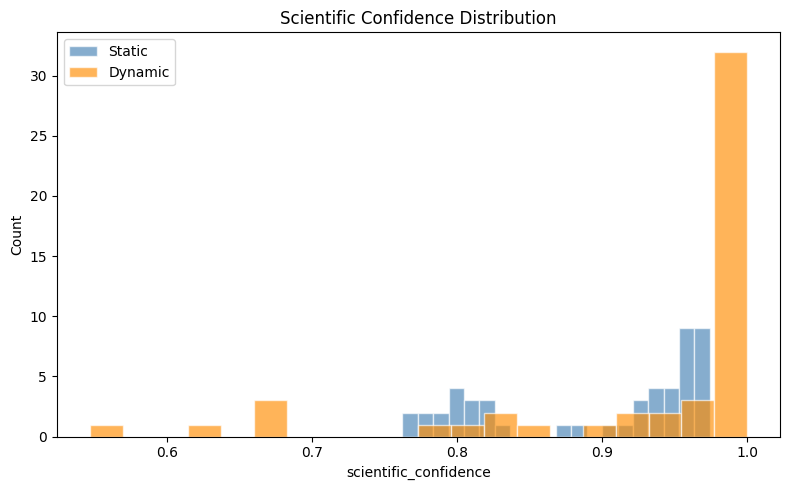

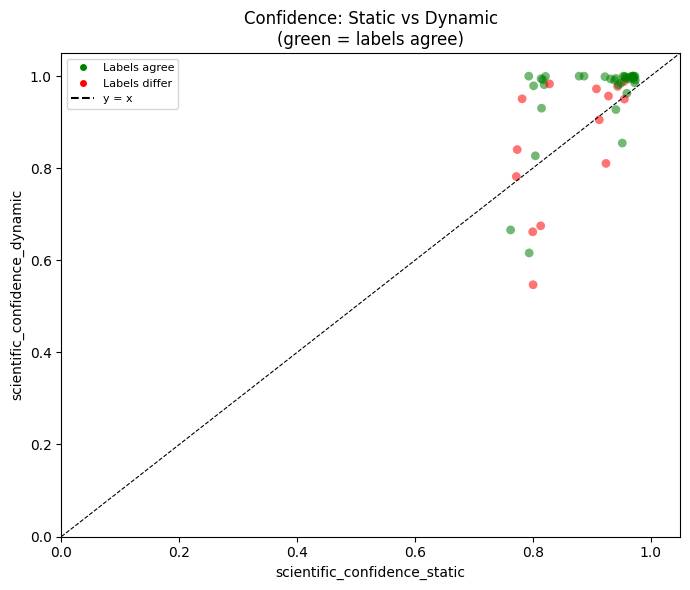

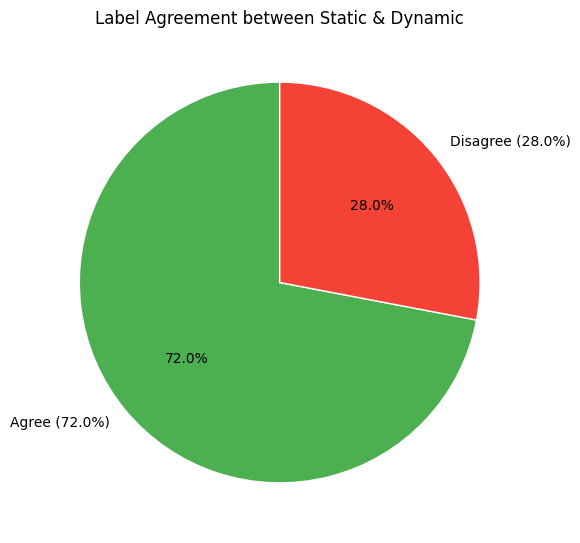

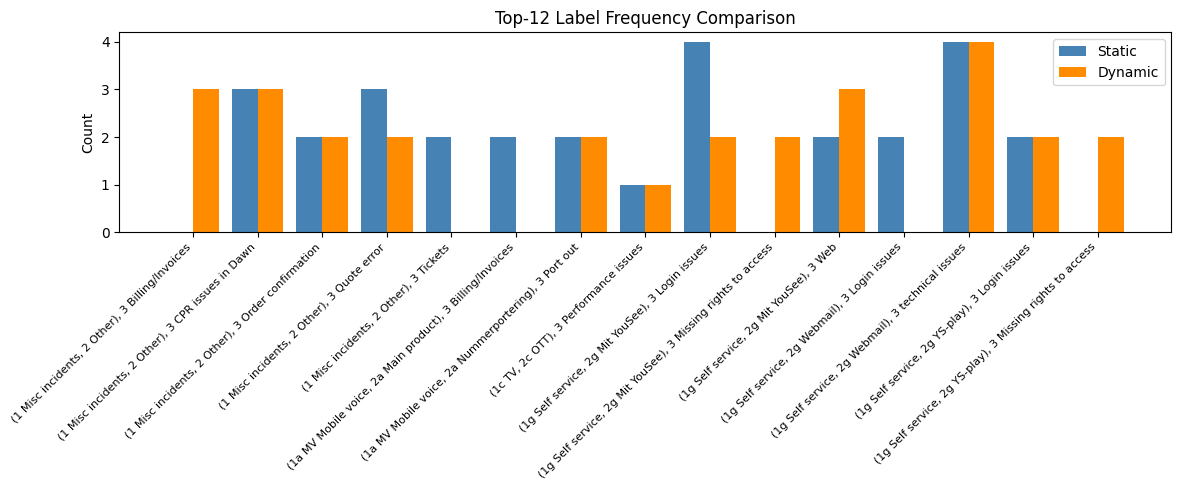

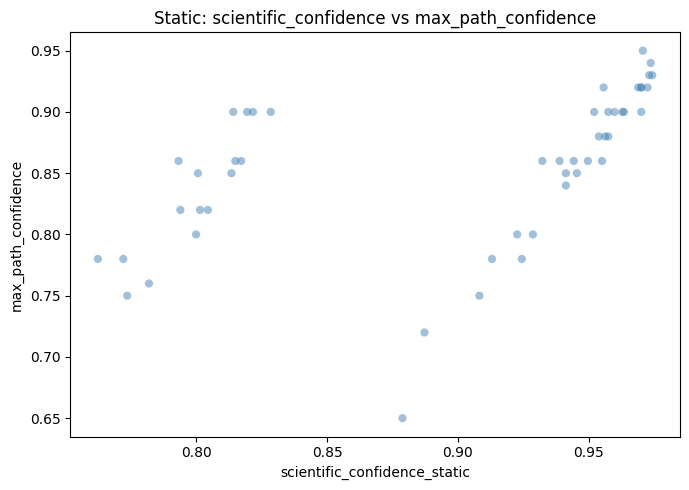

/tmp/ipykernel_9716/1456038513.py:78: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True,


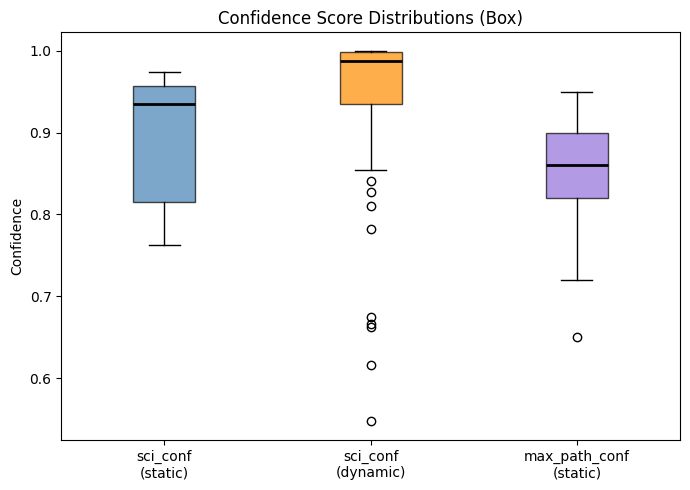

Label agreement: 72.0%  (36 / 50 tickets)


In [11]:

import matplotlib.pyplot as plt
import numpy as np

label_agree = (merged['label_static'] == merged['label_dynamic'])
agree_pct   = label_agree.mean() * 100

# ── 1. Scientific confidence distributions ───────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(merged['scientific_confidence_static'],  bins=20, alpha=0.65, label='Static',  color='steelblue',  edgecolor='white')
ax.hist(merged['scientific_confidence_dynamic'], bins=20, alpha=0.65, label='Dynamic', color='darkorange', edgecolor='white')
ax.set_title('Scientific Confidence Distribution')
ax.set_xlabel('scientific_confidence')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

# ── 2. Scatter: static conf vs dynamic conf ───────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
colors = label_agree.map({True: 'green', False: 'red'})
ax.scatter(merged['scientific_confidence_static'], merged['scientific_confidence_dynamic'],
           c=colors, alpha=0.55, edgecolors='none', s=40)
lims = [0, 1.05]
ax.plot(lims, lims, 'k--', lw=0.8)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_title('Confidence: Static vs Dynamic\n(green = labels agree)')
ax.set_xlabel('scientific_confidence_static')
ax.set_ylabel('scientific_confidence_dynamic')
ax.legend(handles=[
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='green', label='Labels agree'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='red',   label='Labels differ'),
    plt.Line2D([0],[0], linestyle='--', color='k', label='y = x'),
], fontsize=8)
plt.tight_layout()
plt.show()

# ── 3. Label agreement pie ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie([agree_pct, 100 - agree_pct],
       labels=[f'Agree ({agree_pct:.1f}%)', f'Disagree ({100-agree_pct:.1f}%)'],
       colors=['#4caf50', '#f44336'], autopct='%1.1f%%', startangle=90,
       wedgeprops=dict(edgecolor='white'))
ax.set_title('Label Agreement between Static & Dynamic')
plt.tight_layout()
plt.show()

# ── 4. Top label distribution ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
top_n = 12
static_counts  = merged['label_static'].value_counts().head(top_n)
dynamic_counts = merged['label_dynamic'].value_counts().head(top_n)
all_labels = static_counts.index.union(dynamic_counts.index)
x = np.arange(len(all_labels)); w = 0.4
ax.bar(x - w/2, [static_counts.get(l, 0) for l in all_labels],  w, label='Static',  color='steelblue')
ax.bar(x + w/2, [dynamic_counts.get(l, 0) for l in all_labels], w, label='Dynamic', color='darkorange')
ax.set_xticks(x)
ax.set_xticklabels(all_labels, rotation=45, ha='right', fontsize=8)
ax.set_title(f'Top-{top_n} Label Frequency Comparison')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

# ── 5. max_path_confidence vs static scientific_confidence ───────────────────
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(merged['scientific_confidence_static'], merged['max_path_confidence'],
           alpha=0.5, color='steelblue', edgecolors='none', s=35)
ax.set_title('Static: scientific_confidence vs max_path_confidence')
ax.set_xlabel('scientific_confidence_static')
ax.set_ylabel('max_path_confidence')
plt.tight_layout()
plt.show()

# ── 6. Box plots of confidence scores ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
box_data   = [merged['scientific_confidence_static'], merged['scientific_confidence_dynamic'], merged['max_path_confidence']]
box_labels = ['sci_conf\n(static)', 'sci_conf\n(dynamic)', 'max_path_conf\n(static)']
bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
for patch, c in zip(bp['boxes'], ['steelblue', 'darkorange', 'mediumpurple']):
    patch.set_facecolor(c); patch.set_alpha(0.7)
ax.set_title('Confidence Score Distributions (Box)')
ax.set_ylabel('Confidence')
plt.tight_layout()
plt.show()

print(f"Label agreement: {agree_pct:.1f}%  ({label_agree.sum()} / {len(merged)} tickets)")
